![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Specific Interpretation with Forest-Guided Clustering (FGC)

In this Notebook, we will demonstrate how to use the Forest-Guided Clustering (FGC) method for Random Forest models and interpret its results.

--------


## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-random-forest/Bio-4-Tutorial_FGC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-random-forest.txt
# %cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [1]:
import pickle

import numpy as np

from fgclustering import (
    forest_guided_clustering, 
    forest_guided_feature_importance, 
    plot_forest_guided_feature_importance, 
    plot_forest_guided_decision_paths,
    DistanceRandomForestProximity,
    ClusteringKMedoids,
)
from sklearn.metrics import balanced_accuracy_score

import warnings
warnings.filterwarnings('ignore')

We fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [2]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

--------

## Data and Model Loading: The Wisconsin Breast Cancer Dataset

In this notebook, we will work with the **Wisconsin Breast Cancer dataset**, containing 569 samples of 212 malignant and 357 benign tumors. Tumors are described by 30 numeric features computed from a digitized image taken of breast mass (for more details please see descrption [here](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)).

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_breastcancer.png?raw=true" width="700" /></center>

<font size=1> Source: [Link](https://www.kaggle.com/code/midouazerty/breast-cancer-prediction-99)

In the notebook [*Bio-0-Tutorial_RandomForest_Model_BreastCancer.ipynb*](./Bio-0-Tutorial_RandomForest_Model_BreastCancer.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook is the interpretation of the previously trained model.

In [3]:
# Load and unpack the data
with open('../models/model_rf_breastcancer.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)

X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_breastcancer = data_and_model[4]

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(balanced_accuracy_score(y_train, model_breastcancer.predict(X_train))*100,2)} % balanced accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(balanced_accuracy_score(y_test, model_breastcancer.predict(X_test))*100,2)} % balanced accuracy.')

Model Performance on training data: 100.0 % balanced accuracy.
Model Performance on test data: 94.05 % balanced accuracy.


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

--------

## Now, what does my Random Forest model actually think is important in the data?

### Forest-Guided Clustering

**We prepared a small [Introduction to FGC](https://xai-tutorials.readthedocs.io/en/latest/_model_specific_xai/fgc.html) for you, to help you understand how this method works.**

<font color='green'>

#### Question 1: How is the similarity between instances calculated?

<font color='grey'>

#### Your Answer: 
The similarity represents the frequency with which two instances occur in the same terminal nodes of a tree in the Random Forest (RF) model. Intuitively, this defines how close those instances are in the RF model.

<font color='green'>

#### Question 2: How do we choose the number of cluster k for the k-medoids clustering?

<font color='grey'>

#### Your Answer: 
With a scoring system that minimizes the model bias while restricting the model complexity. The model bias measures how well the clustering (FGC with a certain value of ) approximates the expected model, while the variance is related to the model complexity, since complex models usually have a high variance and poor generalization capability.

Now let's use FGC to get some insights into the Random Forest Classification model we loaded above. Unlike feature attribution methods, FGC focuses on identifying subgroups of instances that follow similar decision paths within the forest, thereby revealing structural patterns in the model’s behavior.

To begin, we initialize and run the clustering procedure using the `forest_guided_clustering()` function. This requires selecting a distance metric and a clustering strategy. Currently, the supported distance metric is `DistanceRandomForestProximity()`, which derives similarity between instances based on how often they land in the same leaf nodes across trees.

For clustering, we can choose between `ClusteringKMedoids`, which is suitable for moderate-sized datasets, and `ClusteringClara`, which is designed for larger datasets and provides a scalable approximation of K-Medoids.

*Note: this method is a **global** method meaning it only provides explanations for the full dataset, but not for individual examples.*

In [4]:
# create an FGC instance
fgc = forest_guided_clustering(
    k=(2,4),
    estimator=model_breastcancer, 
    X=X_train, 
    y=y_train, 
    clustering_distance_metric=DistanceRandomForestProximity(), 
    clustering_strategy=ClusteringKMedoids()
)

Using a sample size of 80.00% of the input data for Jaccard Index computation.
Using range k = (2, 4) to optimize k.


Optimizing k: 100%|██████████| 3/3 [00:17<00:00,  5.81s/it]


Optimal number of clusters k = 2

Clustering Evaluation Summary:
 k    Score  Stable  Mean_JI                               Cluster_JI
 2 0.043580    True    0.999                     {1: 0.999, 2: 0.999}
 3 0.077195    True    0.838            {1: 0.956, 2: 0.607, 3: 0.95}
 4 0.043830    True    0.912 {1: 0.976, 2: 0.928, 3: 0.773, 4: 0.973}


Now that we have obtained the optimal clustering of data points guided by the Random Forest decision paths, we can analyze which features are most distinctive across the discovered clusters. The `forest_guided_feature_importance()` function quantifies how important each feature is for differentiating between clusters. Importantly, this analysis does not rely on surrogate models, instead, it directly compares feature distributions across clusters.

- **Local Feature Importance** is computed by comparing the feature distribution within each cluster to the overall feature distribution in the dataset.
- **Global Feature Importance** is obtained by averaging these distances across all clusters, highlighting features that consistently distinguish between clusters.

Because the clustering is derived from sample similarity (based on decision paths) rather than feature selection, we can additionally compute feature importance for any other feature, even those that were not explicitly used during training of the Random Forest model. This allows us to investigate additional confounding variables and assess their relationship to the discovered cluster structure.

To quantify distributional differences, the function supports two distance metrics:

- **Wasserstein Distance**: suitable for predominantly continuous features.
- **Jensen–Shannon Distance**: suitable for categorical or binary features.

These metrics measure how strongly a feature’s distribution differs across clusters relative to the global distribution, thereby capturing how distinctive the feature is for the cluster structure.

In [5]:
feature_importance = forest_guided_feature_importance(
    X=X_train, 
    y=y_train, 
    cluster_labels=fgc.cluster_labels[fgc.best_k],
    feature_importance_distance_metric="wasserstein",
)

100%|██████████| 30/30 [00:00<00:00, 1988.73it/s]


### Global and Local Feature importance provided by FGC

Once we’ve computed the local and global feature importances, we can visualize the results using the `plot_forest_guided_feature_importance()` function. This function displays how important each feature is for distinguishing between the identified clusters, both globally (across all clusters) and locally (within each cluster). 

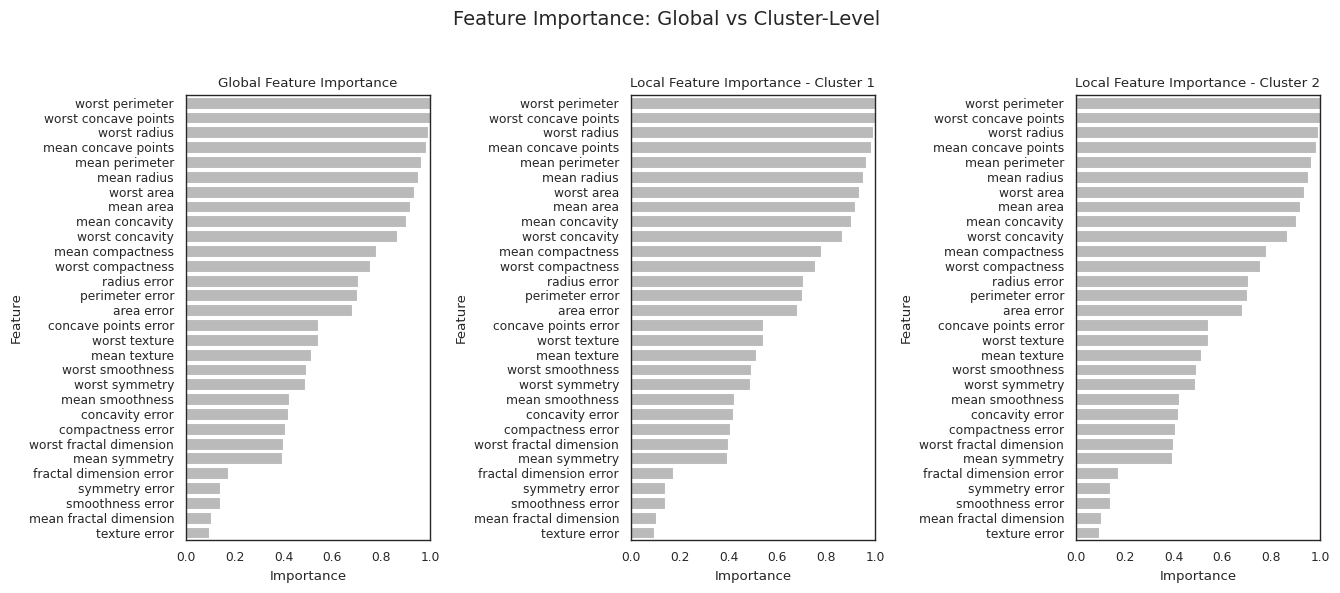

In [6]:
plot_forest_guided_feature_importance(
    feature_importance_local=feature_importance.feature_importance_local,
    feature_importance_global=feature_importance.feature_importance_global,
)

The resulting plot helps interpret which features are most responsible for the forest-defined segmentation of the data. In the example above, we can see that approximately half of the features contribute to distinguishing clusters on a global level. Additionally, the local feature importance highlights that some features are consistently important across both clusters, while others are only influential in a single cluster, indicating feature-cluster-specific effects.

### Visualizing the Decision Paths of the Random Forest Model

Now that we’ve clustered the data using Random Forest decision paths and identified the most important features, we can visually explore how the forest segments the data using the `plot_forest_guided_decision_paths()` function. This visualization provides deeper insights into the decision logic of the Random Forest model by combining heatmaps and feature distribution plots.

The function generates two types of visualizations:

- Heatmap: A cluster-level overview showing target value attribution and feature enrichment or depletion. This allows users to inspect which clusters correspond to which classes or target values. Samples that end up in unexpected clusters may indicate outliers, mislabeled data, or measurement noise.
- Feature Distributions: These plots show the raw feature distributions across clusters without standardization. They provide insight into the within-cluster variance and actual value ranges, helping assess how features vary between and within clusters.

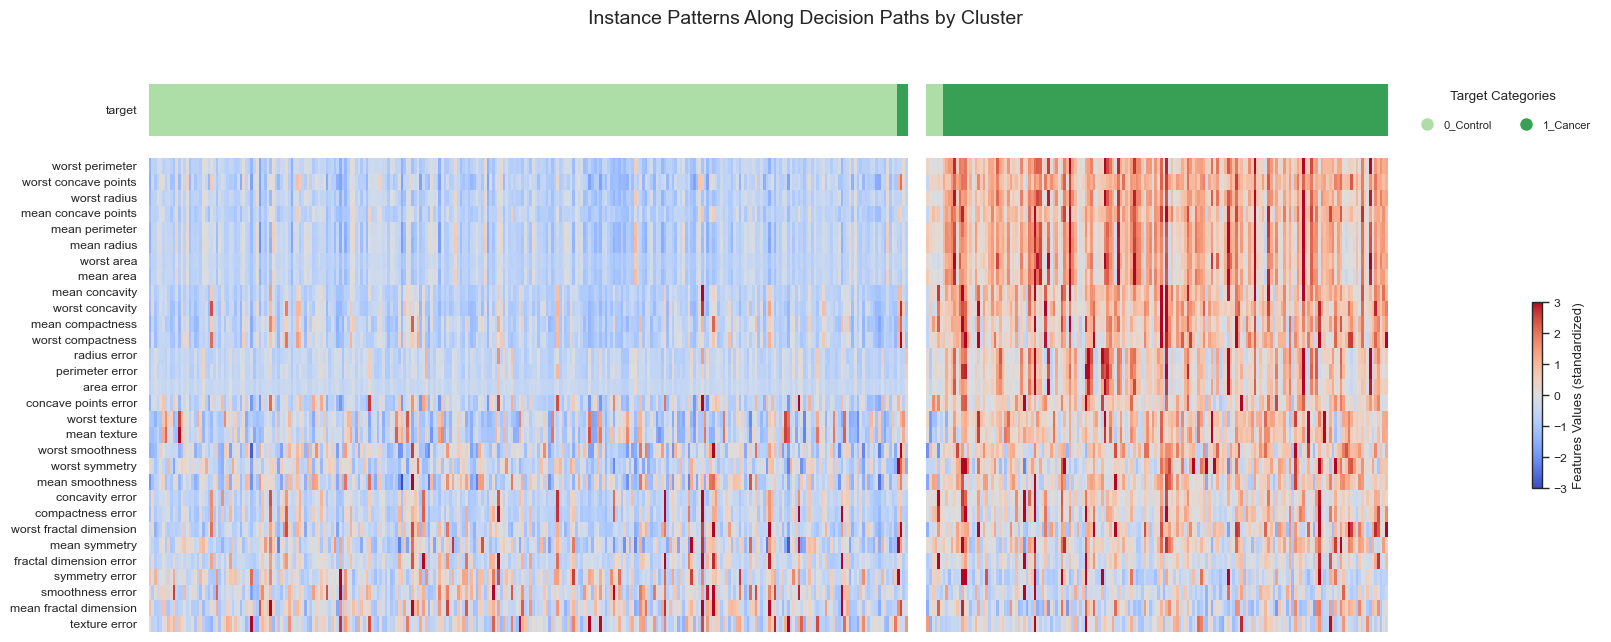

In [7]:
plot_forest_guided_decision_paths(
    data_clustering=feature_importance.data_clustering,
    feature_importance_global=feature_importance.feature_importance_global,
    feature_importance_local=feature_importance.feature_importance_local,
    model_type=fgc.model_type,
    draw_heatmap=True,
    draw_distributions=False,
    draw_dotplot=False,
)

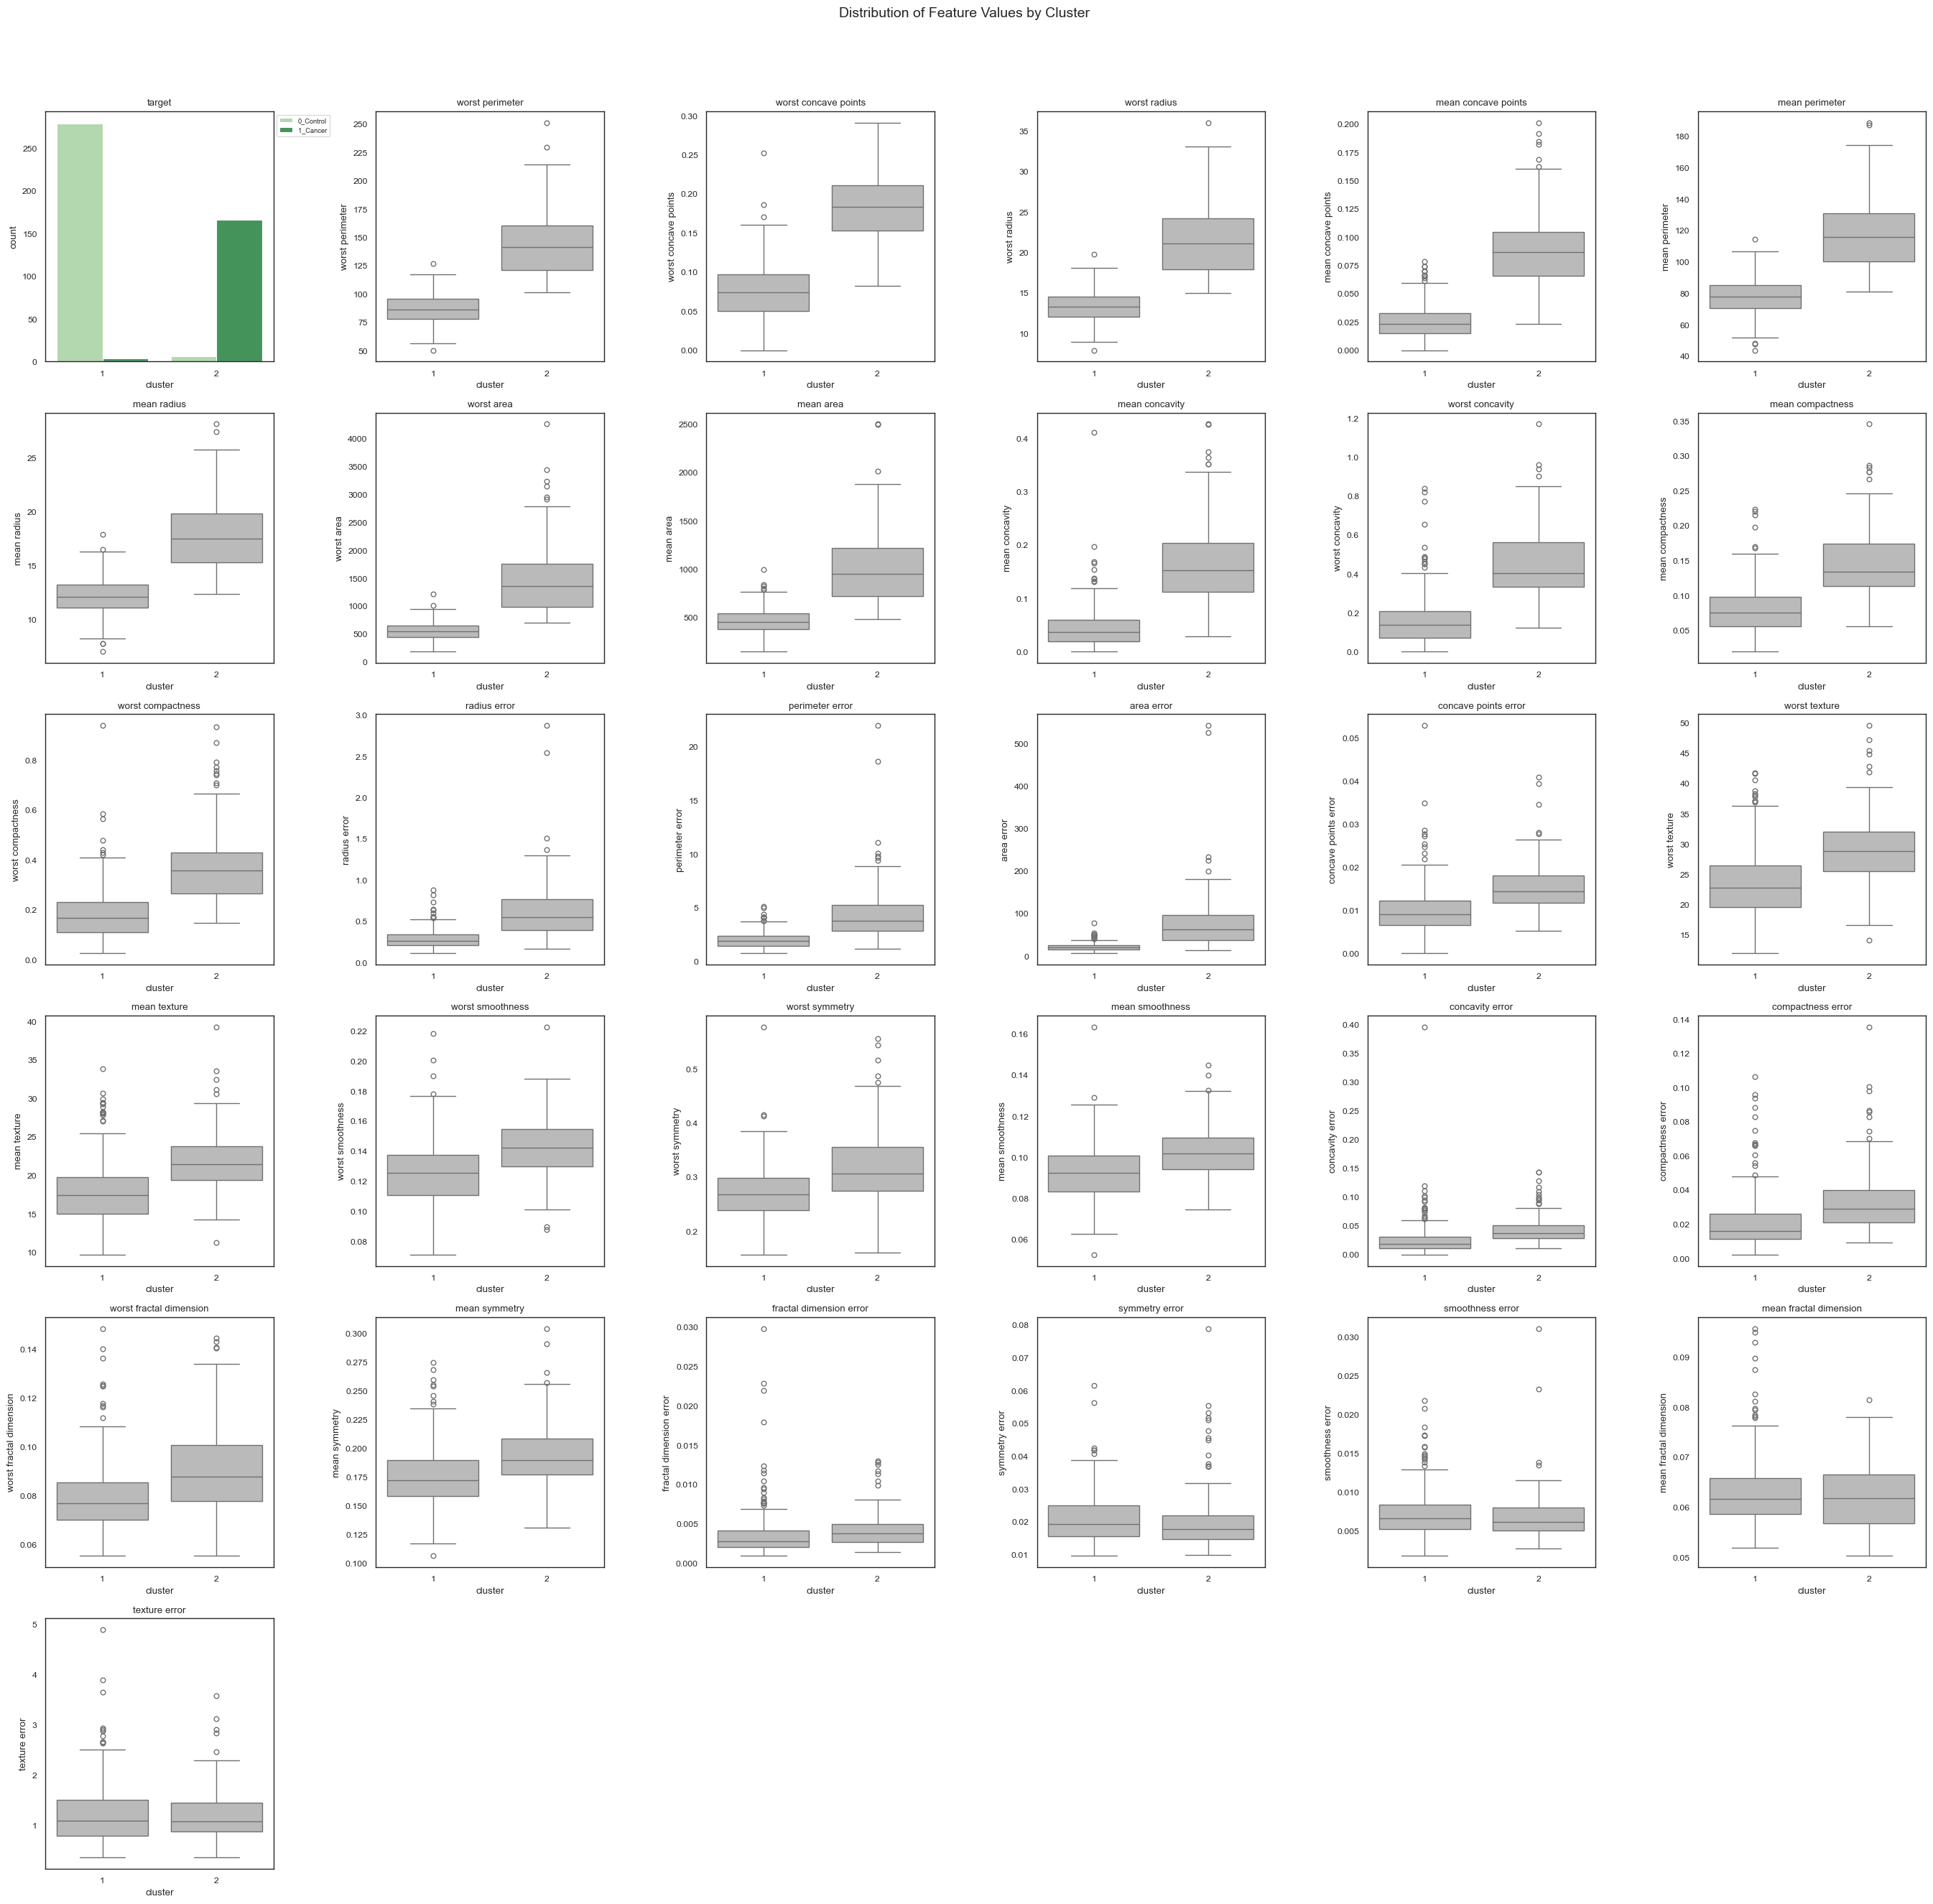

In [8]:
plot_forest_guided_decision_paths(
    data_clustering=feature_importance.data_clustering,
    feature_importance_global=feature_importance.feature_importance_global,
    feature_importance_local=feature_importance.feature_importance_local,
    model_type=fgc.model_type,
    draw_heatmap=False,
    draw_distributions=True,
    draw_dotplot=False,
)

<font color='green'>

#### Question 3: Which conclusions can we draw from the decision path plots above?

<font color='grey'>

#### Your Answer: 


From the resulting plots, we can draw the following conclusions about malignant and benign tumors:

- The two target classes are almost perfectly separated into the two clusters, with only a small number of samples assigned to the “wrong” cluster. These misclassified instances could be further investigated for potential labeling errors or outlier behavior.
- The highest-ranked features in both the feature importance plots and the distribution plots exhibit the most significant differences in values between the clusters.
- Samples in Cluster 0 (corresponding predominantly to benign tumors) consistently show lower values for the most important features compared to samples in Cluster 1 (malignant tumors). Specifically, malignant tumors tend to have more pronounced concave points (worst), greater compactness, and larger radius and perimeter measurements—indicating more irregular and aggressive tumor characteristics.